In [94]:
import numpy as np
from qutip import Bloch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def rz(theta):
    """Rotation matrix around Z-axis by theta radians."""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s, 0], 
                     [s,  c, 0], 
                     [0,  0, 1]])

def ry(theta):
    """Rotation matrix around Y-axis by theta radians."""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c,  0, s], 
                     [0,  1, 0], 
                     [-s, 0, c]])

def make_arc(v_from, v_to, num_steps=40):
    """Generate points tracing the shortest spherical sweep between two unit vectors."""
    dot = np.clip(np.dot(v_from, v_to), -1.0, 1.0)
    theta = np.arccos(dot)
    if theta < 1e-4:
        return None
    t = np.linspace(0, 1, num_steps)
    sin_theta = np.sin(theta)
    # SLERP
    v_from_scaled = np.outer(np.sin((1 - t) * theta) / sin_theta, v_from)
    v_to_scaled = np.outer(np.sin(t * theta) / sin_theta, v_to)
    return (v_from_scaled + v_to_scaled).T  # Returns shape (3, num_steps) for [xs, ys, zs]

def make_right_angle(v1, v2, size=0.15):
    """Generate a small corner square indicator at the origin between two orthogonal vectors."""
    return np.array([size * v1, size * (v1 + v2), size * v2]).T

def q_plot(b_obj, xs, ys, zs, **kwargs):
    """Helper to plot custom 3D lines using QuTiP's internal coordinate transformation ([y, -x, z])."""
    b_obj.axes.plot(ys, -np.array(xs), zs, **kwargs)

def q_text(b_obj, x, y, z, text, **kwargs):
    """Helper to place 3D text using QuTiP's internal coordinate transformation."""
    b_obj.axes.text(y, -x, z, text, **kwargs)

def q_shade(b_obj, xs, ys, zs, color, alpha=0.2):
    """Helper to shade the swept sector using QuTiP's internal coordinate transformation."""
    verts = [(0, 0, 0)]
    for x, y, z in zip(xs, ys, zs):
        verts.append((y, -x, z))
    poly = Poly3DCollection([verts], alpha=alpha, facecolors=color, edgecolors='none', zorder=3)
    b_obj.axes.add_collection3d(poly)

def plot_step(triad_old, triad_new=None):
    """Plot custom rotation steps featuring sweeps, dotted tracks, and color coding."""
    b = Bloch()
    
    # Axis Colors: Colorblind friendly (Okabe-Ito inspired palette)
    # X = Vermillion, Y = Sky Blue, Z = Bluish Green
    c_new = ['#D55E00', '#56B4E9', '#009E73'] # Strong vibrant colors for current state
    c_old = ['#A34500', '#308BBF', '#007555'] # More substantial solid dark colors for background vectors
    
    vec_colors = []
    if triad_new is not None:
        for v in triad_old: b.add_vectors(v)
        vec_colors.extend(c_old)
        for v in triad_new: b.add_vectors(v)
        vec_colors.extend(c_new)
    else:
        for v in triad_old: b.add_vectors(v)
        vec_colors.extend(c_new)

    b.vector_color = vec_colors
    
    # Hide the default origin axes so our new colors stand out without clutter
    b.frame_alpha = 0.05 
    b.render()
    
    t_ref = triad_new if triad_new is not None else triad_old
    
    # 1. Overlay Right Angle Indicator on the top axes (X and Z only to reduce clutter)
    ra_color = '#666666'
    pts = make_right_angle(t_ref[0], t_ref[2], size=0.15)
    q_plot(b, pts[0], pts[1], pts[2], color=ra_color, linewidth=1.5, zorder=4)

    # 2. Overlay Arcs, Shaded Angles & Dotted Traces for old vectors
    if triad_new is not None:
        for i in range(3):
            # Sweeping rotational arc across the gap
            arc = make_arc(triad_old[i], triad_new[i])
            if arc is not None:
                # Shade the solid angle using the arc points
                q_shade(b, arc[0], arc[1], arc[2], color=c_new[i], alpha=0.15)
                
                # Draw a heavy dotted line tracing the EXACT old vector (only if it moved)
                x, y, z = triad_old[i]
                q_plot(b, [0, x*0.95], [0, y*0.95], [0, z*0.95], color=c_old[i], linestyle=':', linewidth=3, zorder=6)
                # Draw the sweep between them
                q_plot(b, arc[0], arc[1], arc[2], color=c_new[i], linestyle='--', linewidth=2.5, zorder=5)

    # 3. Label the active vectors to prevent confusion around what they represent
    labels = [r'$\sigma_x$', r'$\sigma_y$', r'$\sigma_z$']
    for i in range(3):
        # Push the label slightly outside the unit sphere so it isn't covered by the arrow
        vx, vy, vz = t_ref[i] * 1.15
        q_text(b, vx, vy, vz, labels[i], color='black', fontsize=14, zorder=10,
               bbox=dict(facecolor='white', alpha=0.8, edgecolor=c_new[i], boxstyle="round,pad=0.2", lw=1.5))

    return b.fig

# Initial un-rotated triad (X, Y, Z)
triad_0 = [np.array([1, 0, 0]), 
           np.array([0, 1, 0]), 
           np.array([0, 0, 1])]

# Rotation configuration
alpha = np.pi / 10  # Z rotation 
beta  = np.pi / 5  # Y rotation
gamma = np.pi / 5.5  # Z rotation 2

Step 1: Initial Starting Axes
Legend: σ_x (Vermillion) | σ_y (Sky Blue) | σ_z (Bluish Green)


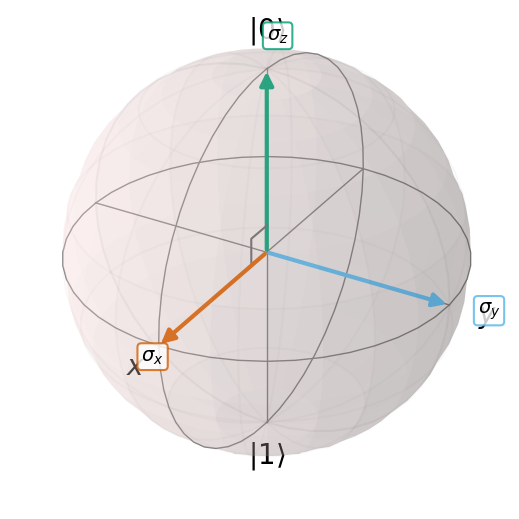

In [95]:
# 1. Starting Bloch sphere with the initial triad
print("Step 1: Initial Starting Axes")
print("Legend: σ_x (Vermillion) | σ_y (Sky Blue) | σ_z (Bluish Green)")
plot_step(triad_0)

Step 2: Rotate around Z by 0.10π
Tracking: Old frame is dotted, rotating along dashed sweeps to the new solid frame.


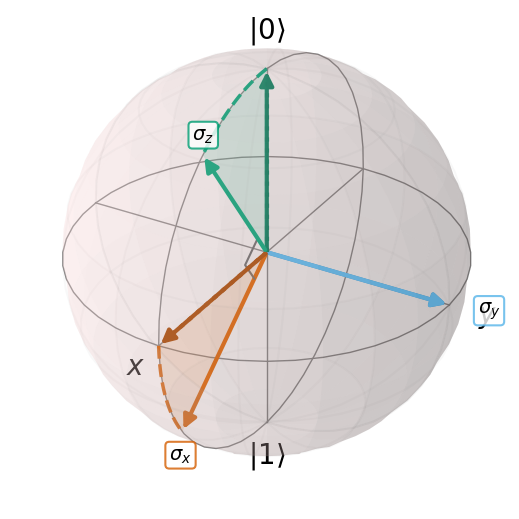

In [100]:
# 2. Rotate the initial axes around Z-axis by alpha
triad_1 = [ry(alpha*2) @ v for v in triad_0]

print(f"Step 2: Rotate around Z by {(alpha/np.pi):.2f}π")
print("Tracking: Old frame is dotted, rotating along dashed sweeps to the new solid frame.")
plot_step(triad_0, triad_1)

Step 3: Rotate active frame around Y by 0.20π


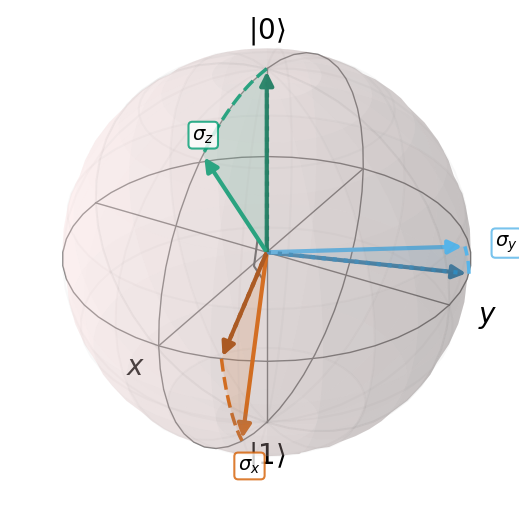

In [97]:
# 3. Rotate the *resulting* axes around the Y-axis by beta
triad_2 = [ry(beta) @ v for v in triad_1]

print(f"Step 3: Rotate active frame around Y by {(beta/np.pi):.2f}π")
plot_step(triad_1, triad_2)

Step 4: Rotate active frame around Z by 0.18π


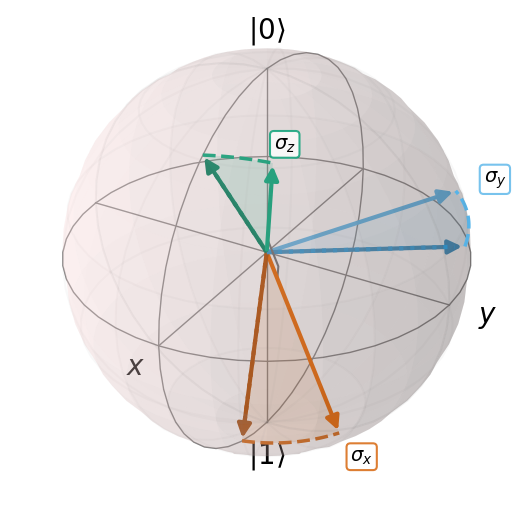

In [98]:
# 4. Rotate the *new* axes around the Z-axis by gamma
triad_3 = [rz(gamma) @ v for v in triad_2]

print(f"Step 4: Rotate active frame around Z by {(gamma/np.pi):.2f}π")
plot_step(triad_2, triad_3)